# Lab 05: The Dark Companion, Two Years Later

**ASTR 457, Fall 2026, posted Sat Oct 3, due Fri Oct 9 by Noon (extended) (fork → PR, as always)**

*Why this lab: every orbit in the literature, from Gaia's black-hole binaries to the planets David Charbonneau talked about on Tuesday, is a posterior distribution over six or seven parameters that nobody can write down in closed form. Sampling it, knowing when the sampler has actually converged, and turning the samples into a number with an honest error bar is the core professional skill of modern astrophysics, and the place where confident, fluent, wrong analyses are most common.*

On Day 1 you watched a star's radial velocity drift over ten nights and inferred an unseen companion from
the slope alone. This is that programme, two and a half years on. Every one of you has your own star:
`data/<your netid>.csv`, with columns `t_days` (time of each spectrum, from the first epoch), `rv_kms`
(the measured radial velocity) and `sigma_rv_kms` (the pipeline's per-epoch uncertainty). The star was
observed in three observing seasons over about 900 days, 28 to 44 epochs in all. It is a **single-lined
spectroscopic binary**: you see one star's lines, the companion contributes no light, and the visible star
follows a Keplerian orbit,

$$v_r(t) = \gamma + K\left[\cos\big(\nu(t) + \omega\big) + e\cos\omega\right],$$

with period $P$, semi-amplitude $K$, eccentricity $e$, argument of periastron $\omega$, a time of periastron
$T_p$, systemic velocity $\gamma$, and $\nu(t)$ the true anomaly (the angle around the orbit, which you get
from Kepler's equation; a function is provided). What you are really after is the **mass function**

$$f(M) = \frac{P K^3 (1 - e^2)^{3/2}}{2\pi G} = \frac{M_2^3 \sin^3 i}{(M_1 + M_2)^2},$$

a lower limit on the companion's mass, in solar masses. If it comes out above about $3\,M_\odot$ for a
Sun-like primary, you have a black hole candidate, the way Gaia BH1 was found (El-Badry et al. 2023, the Sep 8
colloquium). In the units of your file, $f(M) = 1.0361\times10^{-7}\,(1-e^2)^{3/2} K^3 P$ with $K$ in km/s
and $P$ in days.

I know your true $P$, $K$, $e$ and $f(M)$. You don't, your classmates' stars are different, and so is the
sampling. **One more thing I know and you don't: the quoted `sigma_rv_kms` is not the whole error.** Real
radial velocities carry an extra scatter, called jitter, from the star's own surface and from template
mismatch, and it is not in the pipeline number.

**How this is graded.** As always, on whether your answers are *right* and your uncertainties are *honest*:
your reported $P$, $K$, $e$ and $f(M)$ are compared to your truth in units of your own reported uncertainty.
Anti-sandbagging cap: your $\sigma_K$ may not exceed $3\times$ a reference posterior width I compute for your
dataset. Padded error bars lose points like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document it in Part 4. You
may be selected to defend this lab orally; the defense is easy if you did the work.

Weights: Part 1 15%, Part 2 40%, Part 3 35%, Part 4 10%.


In [2]:
%pip install emcee corner astropy

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.optimize import minimize
from astropy.timeseries import LombScargle

NETID = 'siyaoxu2'   # <-- set this
d = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True)
t, rv, sig = d['t_days'], d['rv_kms'], d['sigma_rv_kms']
print(f"{t.size} epochs over {t.max() - t.min():.0f} days; median quoted error {np.median(sig):.2f} km/s")

def kepler_rv(t, P, K, e, omega, Tp, gamma):
    """Radial velocity of the visible star in a Keplerian orbit.
    P period [d], K semi-amplitude [km/s], e eccentricity, omega argument of periastron [rad],
    Tp a time of periastron [d], gamma systemic velocity [km/s]. Solves Kepler's equation by Newton iteration."""
    M = 2. * np.pi * ((t - Tp) / P % 1.0)            # mean anomaly
    E = M.copy()                                     # eccentric anomaly
    for _ in range(30):
        E = E - (E - e * np.sin(E) - M) / (1. - e * np.cos(E))
    nu = 2. * np.arctan2(np.sqrt(1. + e) * np.sin(E / 2.), np.sqrt(1. - e) * np.cos(E / 2.))   # true anomaly
    return gamma + K * (np.cos(nu + omega) + e * np.cos(omega))

def mass_function(P, K, e):
    """f(M) in solar masses, for P in days and K in km/s."""
    return 1.0361e-7 * (1. - e**2)**1.5 * K**3 * P

40 epochs over 887 days; median quoted error 1.71 km/s


## Part 1: Look first, then find the period (15%)

Plot the radial velocities against time with their error bars. Then find candidate orbital periods with a
Lomb-Scargle periodogram of the velocities (`astropy.timeseries.LombScargle`, Day 7's periodogram, formally
taught on Oct 20/22; for now it is a tool that ranks periods). Plot the periodogram. Then, for the best two or
three candidate periods, phase-fold the data and look.

Answer, in a few sentences: how many candidate periods are plausible from the periodogram alone, and why does
a Lomb-Scargle periodogram (which fits a *sinusoid*) not settle the question for an eccentric orbit? What
feature of the sampling (look at the gaps) produces the other peaks?


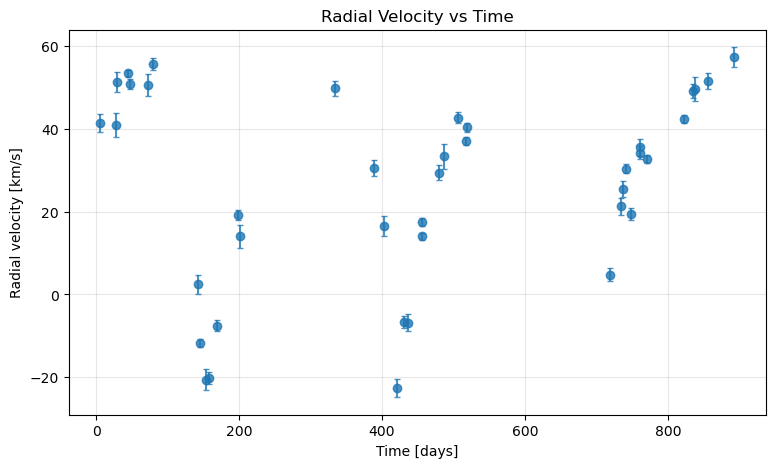

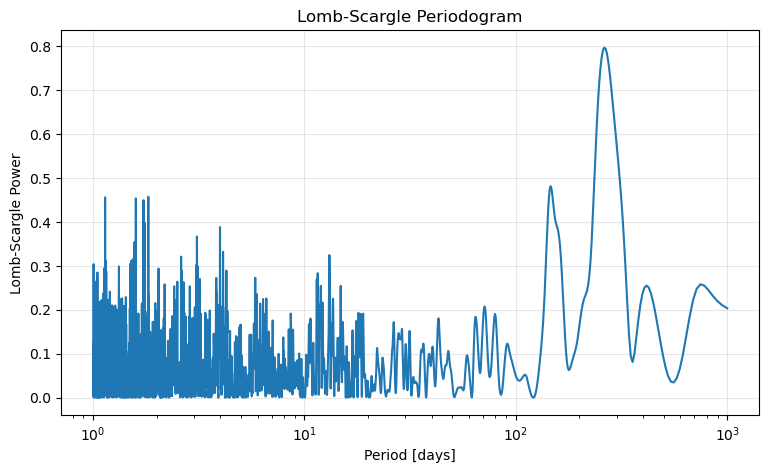

Top candidate periods:
1: P = 261.966 days
2: P = 278.404 days
3: P = 247.361 days


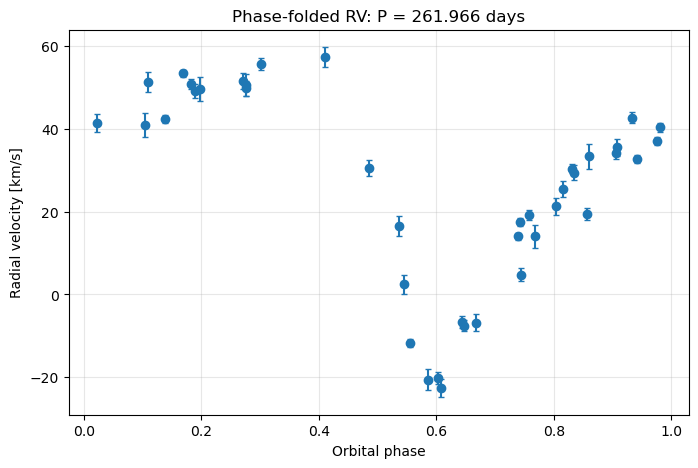

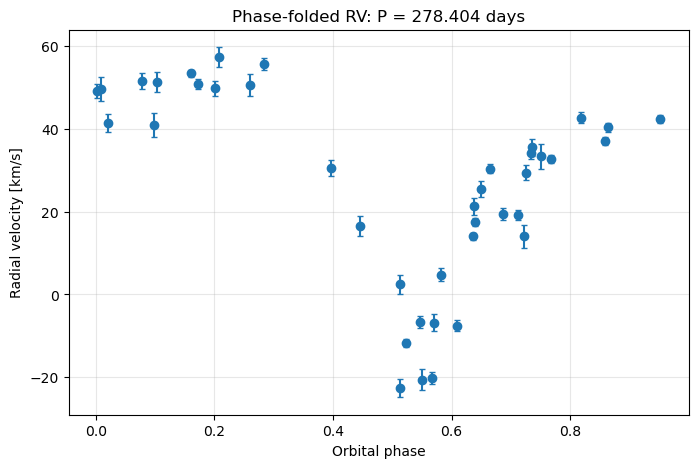

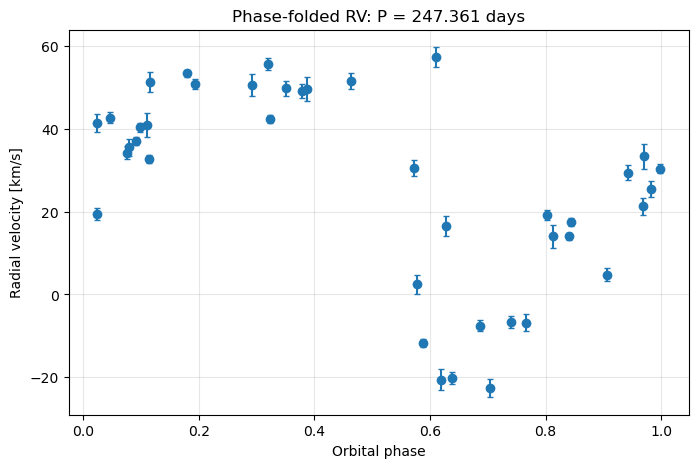

In [6]:
# Part 1: your work here

plt.figure(figsize=(9, 5))

plt.errorbar(
    t, rv,
    yerr=sig,
    fmt='o',
    capsize=2,
    alpha=0.8
)

plt.xlabel("Time [days]")
plt.ylabel("Radial velocity [km/s]")
plt.title("Radial Velocity vs Time")
plt.grid(alpha=0.3)
plt.show()


ls = LombScargle(t, rv, dy=sig)

# Search periods from 1 day to 1000 days
frequency, power = ls.autopower(
    minimum_frequency=1/1000,
    maximum_frequency=1/1,
    samples_per_peak=20
)

period = 1 / frequency

plt.figure(figsize=(9, 5))
plt.plot(period, power)

plt.xlabel("Period [days]")
plt.ylabel("Lomb-Scargle Power")
plt.title("Lomb-Scargle Periodogram")
plt.xscale("log")
plt.grid(alpha=0.3)
plt.show()

order = np.argsort(power)[::-1]

candidate_periods = []

for i in order:
    P = period[i]

    if all(abs(P - oldP) / oldP > 0.05 for oldP in candidate_periods):
        candidate_periods.append(P)

    if len(candidate_periods) == 3:
        break

print("Top candidate periods:")
for j, P in enumerate(candidate_periods):
    print(f"{j+1}: P = {P:.3f} days")


for P in candidate_periods:

    phase = (t % P) / P

    idx = np.argsort(phase)

    plt.figure(figsize=(8, 5))

    plt.errorbar(
        phase[idx],
        rv[idx],
        yerr=sig[idx],
        fmt='o',
        capsize=2
    )

    plt.xlabel("Orbital phase")
    plt.ylabel("Radial velocity [km/s]")
    plt.title(f"Phase-folded RV: P = {P:.3f} days")
    plt.grid(alpha=0.3)

    plt.show()

**ANSWER (a few sentences):**

There are about two to three plausible candidate periods based on the Lomb Scargle periodogram, because several peaks have comparable power.

## Part 2: Sample the posterior (40%)

Fit the six orbital parameters **plus a jitter term** $s$ with `emcee`. The likelihood for epoch $i$ is
Gaussian with variance $\sigma_i^2 + s^2$; write it out (including the $\log$ of the variance, which is not a
constant once $s$ is a parameter). You will need to:

1. **Write the log-likelihood, log-prior and log-posterior.** State every prior and justify it in one line
   each. Two traps: $\omega$ and $T_p$ are periodic ($T_p$ is only defined modulo $P$), and `emcee` does not
   wrap angles, so a hard prior wall at $0$ or $2\pi$ can cut a posterior mode in half. Either bound each of
   them within half a period of your starting value, or reparameterize with $\sqrt{e}\cos\omega$ and
   $\sqrt{e}\sin\omega$ (which also gives a uniform prior on $e$ without a wall at zero). Jitter is
   positive: sample $\ln s$.
2. **Start the walkers sensibly.** A maximum-likelihood fit from each plausible Part 1 period, with several
   starting $\omega$ and $T_p$ each, then compare the log-likelihoods; start the walkers in a small ball
   around the best one. That comparison is the check: report the log-likelihood of the runner-up.
3. **Run, then decide when it is done.** Compute the integrated autocorrelation time $\tau$ for every
   parameter (`sampler.get_autocorr_time`). Here $\tau$ is about 50 to 100 steps, so 64 walkers for
   10,000 steps is plenty (a few minutes) and `emcee`'s own rule is a chain longer than $50\tau$. A
   common choice is to discard a few $\tau$ as burn-in and thin by about $\tau/2$; say what you chose
   and why. Plot the chains. If $\tau$ cannot be estimated, your chain is too short; say so and fix it.
4. **Corner plot.** Which parameters are correlated, and why physically?
5. **Report** $P$, $K$, $e$, $\gamma$, the jitter $s$, and $f(M)$, each as a median and 68% interval.
   **$f(M)$ is computed for every posterior sample**, not from the medians of $P$, $K$ and $e$; explain in
   one sentence why that matters.
6. **Posterior predictive check.** Draw a few hundred orbits from the posterior and plot them over the data,
   phase-folded at the median period. Plot the normalized residuals with the *total* error bar
   $\sqrt{\sigma_i^2 + s^2}$. Is what is left noise?

**FINAL ANSWER:** $P = $ ___ $\pm$ ___ d, $K = $ ___ $\pm$ ___ km/s, $e = $ ___ $\pm$ ___, $\gamma = $ ___ $\pm$ ___ km/s, jitter $s = $ ___ $\pm$ ___ km/s, $f(M) = $ ___ $\pm$ ___ $M_\odot$. Is your companion a black-hole candidate? One sentence.


In [7]:
# Part 2: your work here

def direct_loglike(z):
    """
    Parameters:
    z = [lnP, lnK, e, omega, Tp, gamma, lns]
    """
    lnP, lnK, e, omega, Tp, gamma, lns = z

    P = np.exp(lnP)
    K = np.exp(lnK)
    s = np.exp(lns)

    if not (0.0 <= e < 0.99):
        return -np.inf

    model = kepler_rv(t, P, K, e, omega, Tp, gamma)

    var = sig**2 + s**2

    return -0.5 * np.sum(
        (rv - model)**2 / var
        + np.log(2 * np.pi * var)
    )


def neg_direct_loglike(z):
    ll = direct_loglike(z)

    if not np.isfinite(ll):
        return 1e100

    return -ll


rv_scale = max(np.std(rv), np.median(sig), 1.0)
K_guess = max(0.5 * np.ptp(rv), 0.1)
gamma_guess = np.median(rv)
s_guess = max(np.median(sig), 0.05)

candidate_results = []

for P0 in candidate_periods:

    best_for_period = None

    P_lo = 0.80 * P0
    P_hi = 1.20 * P0

    omega_starts = np.linspace(0, 2*np.pi, 4, endpoint=False)
    phase_starts = np.linspace(0, 1, 4, endpoint=False)

    for omega0 in omega_starts:

        for phase0 in phase_starts:

            e0 = 0.2
            Tp0 = t.min() + phase0 * P0

            x0 = np.array([
                np.log(P0),
                np.log(K_guess),
                e0,
                omega0,
                Tp0,
                gamma_guess,
                np.log(s_guess)
            ])

            bounds = [
                (np.log(P_lo), np.log(P_hi)),       # ln P
                (np.log(1e-4), np.log(max(100, 10*np.ptp(rv)))),  # ln K
                (0.0, 0.99),                       # e
                (0.0, 2*np.pi),                    # omega
                (Tp0 - 0.5*P0, Tp0 + 0.5*P0),      # Tp
                (gamma_guess - 10*rv_scale,
                 gamma_guess + 10*rv_scale),        # gamma
                (np.log(1e-4),
                 np.log(max(100, 10*rv_scale)))      # ln s
            ]

            result = minimize(
                neg_direct_loglike,
                x0,
                method="Powell",
                bounds=bounds
            )

            if result.success or np.isfinite(result.fun):

                logL = -result.fun

                if (best_for_period is None or
                    logL > best_for_period["logL"]):

                    best_for_period = {
                        "P_seed": P0,
                        "P_bounds": (P_lo, P_hi),
                        "logL": logL,
                        "x": result.x
                    }

    candidate_results.append(best_for_period)


# Sort from highest likelihood to lowest
candidate_results = sorted(
    candidate_results,
    key=lambda x: x["logL"],
    reverse=True
)

print("Maximum-likelihood comparison:\n")

for i, r in enumerate(candidate_results):

    x = r["x"]

    P_fit = np.exp(x[0])
    K_fit = np.exp(x[1])
    e_fit = x[2]
    omega_fit = x[3]
    Tp_fit = x[4]
    gamma_fit = x[5]
    s_fit = np.exp(x[6])

    print(
        f"{i+1}: seed P = {r['P_seed']:.3f} d, "
        f"fit P = {P_fit:.3f} d, "
        f"logL = {r['logL']:.2f}"
    )


best = candidate_results[0]

print("\nBEST log-likelihood =", best["logL"])

if len(candidate_results) > 1:
    print(
        "RUNNER-UP log-likelihood =",
        candidate_results[1]["logL"]
    )

Maximum-likelihood comparison:

1: seed P = 261.966 d, fit P = 265.825 d, logL = -109.82
2: seed P = 247.361 d, fit P = 265.807 d, logL = -109.82
3: seed P = 278.404 d, fit P = 265.825 d, logL = -109.82

BEST log-likelihood = -109.82470405100986
RUNNER-UP log-likelihood = -109.82474823779206


In [9]:
# ============================================================
# Part 2.1
# Prior and posterior
# ============================================================

best_x = best["x"]

P_hat = np.exp(best_x[0])
K_hat = np.exp(best_x[1])
e_hat = best_x[2]
omega_hat = best_x[3]
Tp_hat = best_x[4]
gamma_hat = best_x[5]
s_hat = np.exp(best_x[6])

P_lo, P_hi = best["P_bounds"]

# Convert eccentricity + omega to h, q
h_hat = np.sqrt(e_hat) * np.cos(omega_hat)
q_hat = np.sqrt(e_hat) * np.sin(omega_hat)

# Prior ranges
K_min = 1e-4
K_max = max(100, 10*np.ptp(rv))

s_min = 1e-4
s_max = max(100, 10*rv_scale)

gamma_min = gamma_guess - 10*rv_scale
gamma_max = gamma_guess + 10*rv_scale

# One representative orbit for Tp
Tp_min = Tp_hat - 0.5 * P_hat
Tp_max = Tp_hat + 0.5 * P_hat


def unpack(theta):
    """
    theta = [lnP, lnK, h, q, Tp, gamma, lns]
    """

    lnP, lnK, h, q, Tp, gamma, lns = theta

    P = np.exp(lnP)
    K = np.exp(lnK)

    e = h**2 + q**2
    omega = np.arctan2(q, h)

    s = np.exp(lns)

    return P, K, e, omega, Tp, gamma, s


def log_prior(theta):

    P, K, e, omega, Tp, gamma, s = unpack(theta)

    if not (P_lo < P < P_hi):
        return -np.inf

    if not (K_min < K < K_max):
        return -np.inf
    if not (0 <= e < 0.99):
        return -np.inf

    if not (Tp_min < Tp < Tp_max):
        return -np.inf

    if not (gamma_min < gamma < gamma_max):
        return -np.inf

    if not (s_min < s < s_max):
        return -np.inf

    return 0.0


def log_likelihood(theta):

    P, K, e, omega, Tp, gamma, s = unpack(theta)

    if e >= 1:
        return -np.inf

    model = kepler_rv(
        t,
        P,
        K,
        e,
        omega,
        Tp,
        gamma
    )

    var = sig**2 + s**2

    return -0.5 * np.sum(
        (rv - model)**2 / var
        + np.log(2*np.pi*var)
    )


def log_probability(theta):

    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta)

In [10]:
# ============================================================
# Part 2.2 + 2.3
# Run emcee
# ============================================================

ndim = 7
nwalkers = 64
nsteps = 10000

center = np.array([
    np.log(P_hat),
    np.log(K_hat),
    h_hat,
    q_hat,
    Tp_hat,
    gamma_hat,
    np.log(s_hat)
])

scales = np.array([
    1e-3,                     # lnP
    2e-3,                     # lnK
    0.01,                     # h
    0.01,                     # q
    0.01 * P_hat,             # Tp
    0.01 * rv_scale,          # gamma
    0.02                      # lns
])

rng = np.random.default_rng(457)

pos = np.zeros((nwalkers, ndim))

for i in range(nwalkers):

    while True:

        trial = center + scales * rng.normal(size=ndim)

        if np.isfinite(log_prior(trial)):
            pos[i] = trial
            break


sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_probability
)

sampler.run_mcmc(
    pos,
    nsteps,
    progress=True
)

100%|████████████████████████████████████| 10000/10000 [01:26<00:00, 115.07it/s]


State([[  5.58774309   3.57541176  -0.62455547   0.39321887 147.79217986
   31.93010209   1.38053499]
 [  5.58777489   3.55179609  -0.63224904   0.35560036 149.48115455
   31.7363858    1.22335298]
 [  5.59090208   3.58893861  -0.63231117   0.33346459 150.2371636
   31.5850659    1.41289703]
 [  5.58140477   3.58259124  -0.6009652    0.39292698 149.9030064
   31.89700253   1.27518167]
 [  5.58440262   3.61147529  -0.58148862   0.40674909 147.34486998
   31.71227828   1.35635455]
 [  5.58126813   3.56277188  -0.61893725   0.40448466 148.23764448
   31.80122952   1.26448134]
 [  5.57730856   3.62795946  -0.60143781   0.46172883 148.21417247
   32.26088649   1.27313493]
 [  5.58633727   3.62389328  -0.61171296   0.42688282 147.97174508
   32.10159962   1.24910499]
 [  5.58498173   3.58782456  -0.58158061   0.39912605 147.18492188
   31.42158506   1.47229897]
 [  5.58998863   3.57000166  -0.60720431   0.39985881 149.02223974
   32.1295556    1.52072647]
 [  5.59113244   3.59577008  -0.5822

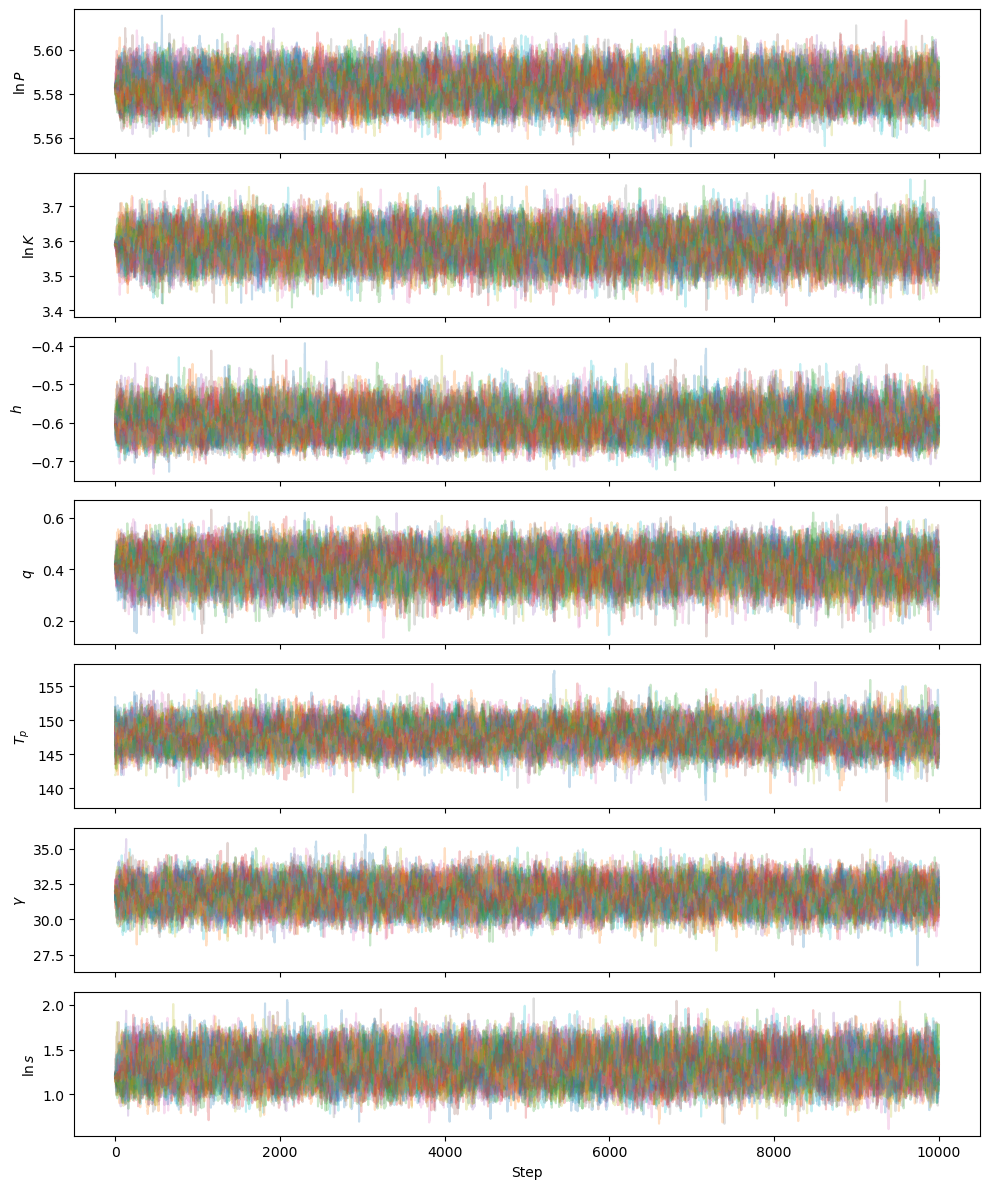

Integrated autocorrelation times:
$\ln P$: 75.0 steps
$\ln K$: 80.9 steps
$h$: 74.3 steps
$q$: 76.6 steps
$T_p$: 78.7 steps
$\gamma$: 71.6 steps
$\ln s$: 76.6 steps

Chain length / max(tau) = 123.67487708312918
Chain satisfies emcee's > 50 tau rule.


In [11]:
# ============================================================
# Part 2.3
# Convergence diagnostics
# ============================================================

chain = sampler.get_chain()

labels = [
    r"$\ln P$",
    r"$\ln K$",
    r"$h$",
    r"$q$",
    r"$T_p$",
    r"$\gamma$",
    r"$\ln s$"
]

fig, axes = plt.subplots(
    ndim,
    1,
    figsize=(10, 12),
    sharex=True
)

for i in range(ndim):

    axes[i].plot(
        chain[:, :, i],
        alpha=0.25
    )

    axes[i].set_ylabel(labels[i])

axes[-1].set_xlabel("Step")

plt.tight_layout()
plt.show()


try:

    tau = sampler.get_autocorr_time()

    print("Integrated autocorrelation times:")

    for name, value in zip(labels, tau):
        print(f"{name}: {value:.1f} steps")

    print(
        "\nChain length / max(tau) =",
        nsteps / np.max(tau)
    )

    if nsteps > 50 * np.max(tau):
        print("Chain satisfies emcee's > 50 tau rule.")
    else:
        print("WARNING: chain is shorter than 50 tau.")

except emcee.autocorr.AutocorrError as err:

    tau = err.tau

    print("Autocorrelation time could not yet be reliably estimated.")
    print("Estimated tau =", tau)
    print("The chain may need to be longer.")

Burn-in = 242
Thin = 40
Posterior samples retained = 15552


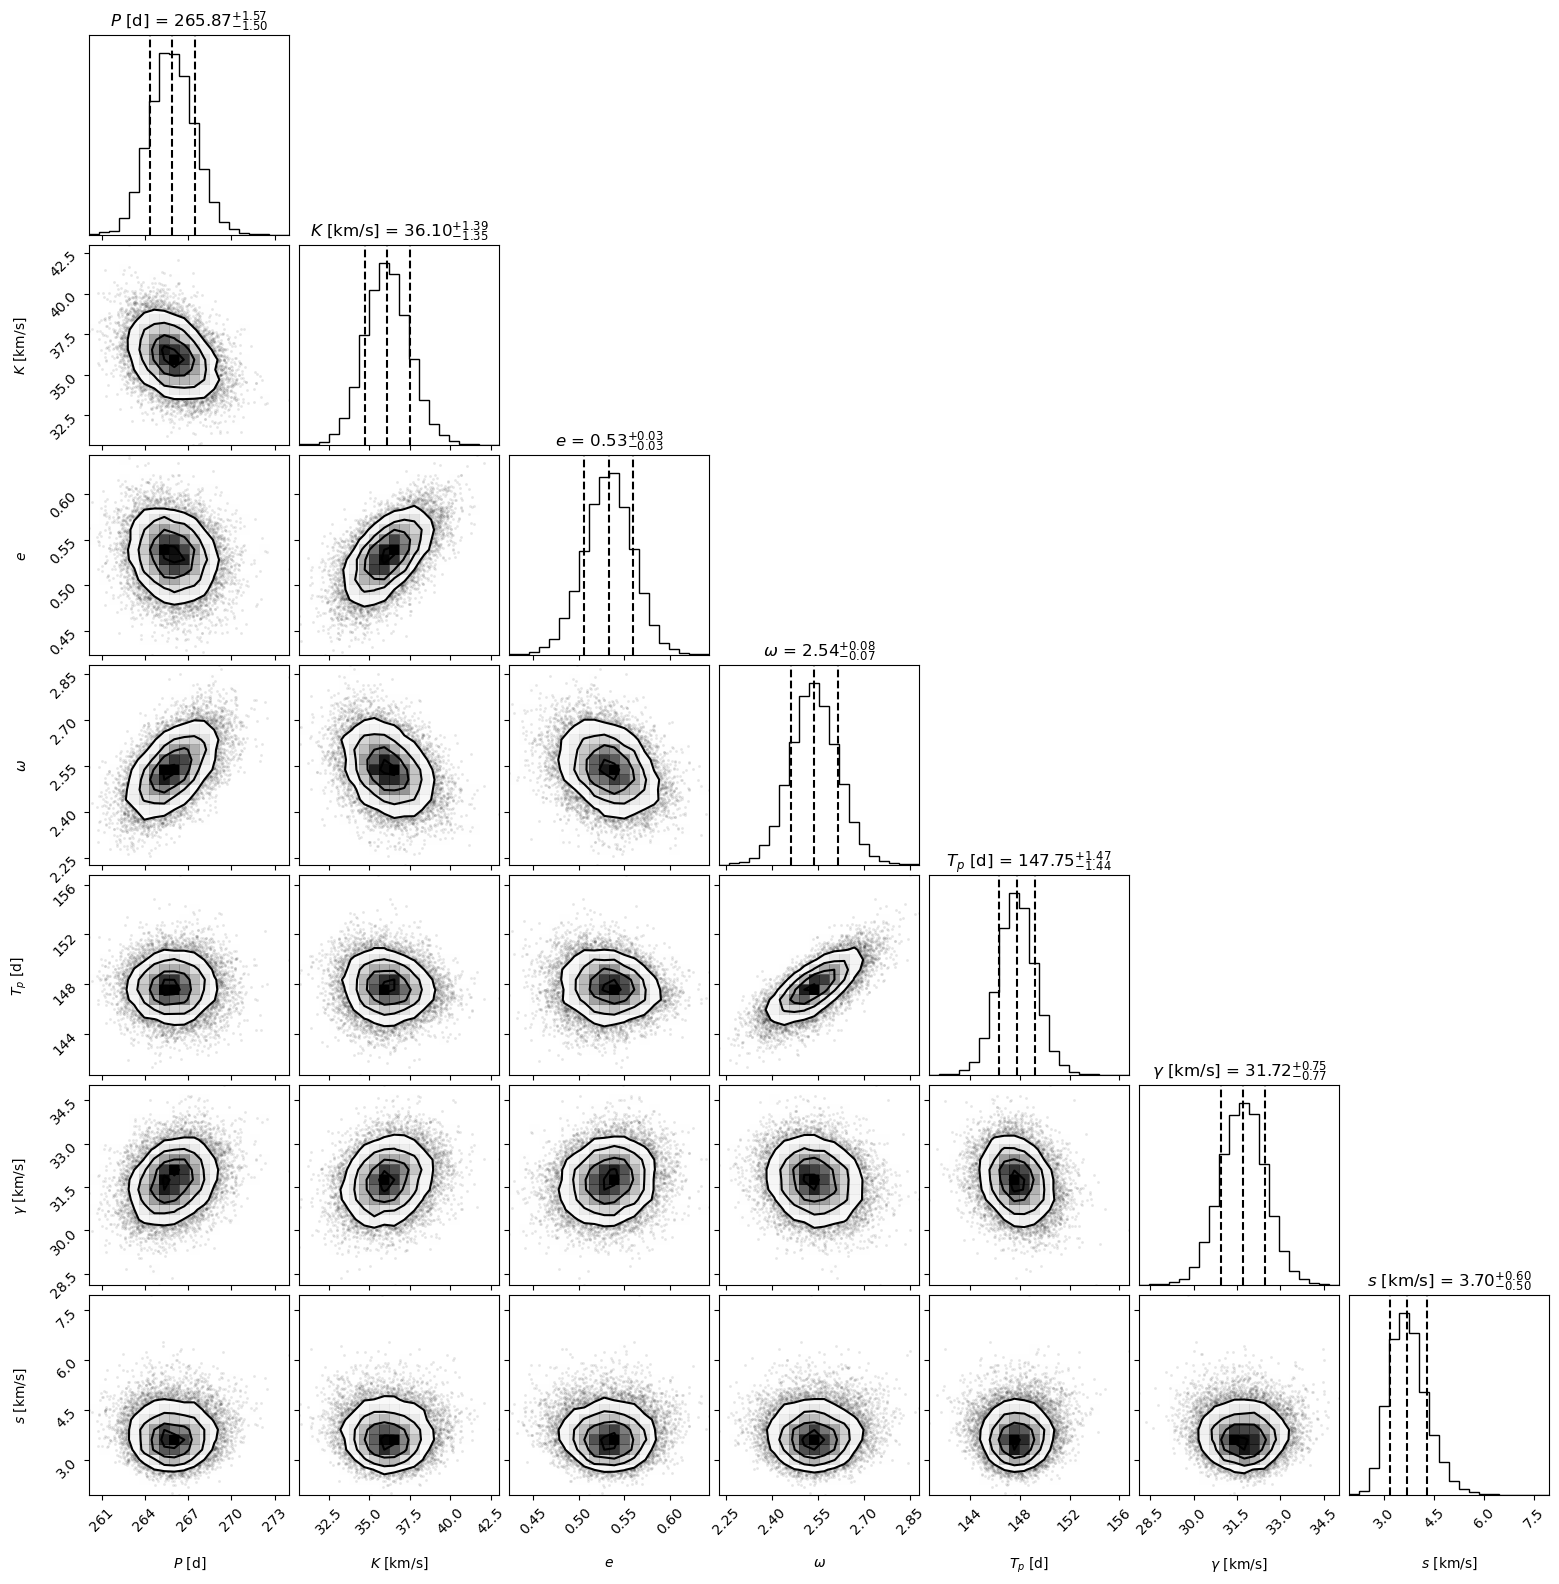

In [12]:
# ============================================================
# Part 2.3 + 2.4
# Burn-in, thinning, corner plot
# ============================================================

tau_max = np.max(tau)

burnin = int(3 * tau_max)
thin = max(1, int(tau_max / 2))

print("Burn-in =", burnin)
print("Thin =", thin)

flat_samples = sampler.get_chain(
    discard=burnin,
    thin=thin,
    flat=True
)

print("Posterior samples retained =", len(flat_samples))


# Convert sampled parameters into physical parameters
lnP_s = flat_samples[:, 0]
lnK_s = flat_samples[:, 1]
h_s = flat_samples[:, 2]
q_s = flat_samples[:, 3]
Tp_s = flat_samples[:, 4]
gamma_s = flat_samples[:, 5]
lns_s = flat_samples[:, 6]

P_s = np.exp(lnP_s)
K_s = np.exp(lnK_s)

e_s = h_s**2 + q_s**2

omega_s_raw = np.arctan2(q_s, h_s)

omega_s = omega_hat + (
    (omega_s_raw - omega_hat + np.pi) % (2*np.pi)
    - np.pi
)

s_s = np.exp(lns_s)

physical_samples = np.column_stack([
    P_s,
    K_s,
    e_s,
    omega_s,
    Tp_s,
    gamma_s,
    s_s
])


corner.corner(
    physical_samples,
    labels=[
        r"$P$ [d]",
        r"$K$ [km/s]",
        r"$e$",
        r"$\omega$",
        r"$T_p$ [d]",
        r"$\gamma$ [km/s]",
        r"$s$ [km/s]"
    ],
    show_titles=True,
    quantiles=[0.16, 0.50, 0.84]
)

plt.show()

In [13]:
# ============================================================
# Part 2.5
# Parameter summaries and mass function
# ============================================================

fM_s = mass_function(
    P_s,
    K_s,
    e_s
)


def summarize(x):

    q16, q50, q84 = np.percentile(
        x,
        [16, 50, 84]
    )

    lower = q50 - q16
    upper = q84 - q50

    return q50, lower, upper


names = [
    "P [days]",
    "K [km/s]",
    "e",
    "gamma [km/s]",
    "jitter s [km/s]",
    "f(M) [Msun]"
]

arrays = [
    P_s,
    K_s,
    e_s,
    gamma_s,
    s_s,
    fM_s
]

print("Posterior summaries:\n")

summaries = {}

for name, arr in zip(names, arrays):

    med, lo, hi = summarize(arr)

    summaries[name] = (med, lo, hi)

    print(
        f"{name}: "
        f"{med:.5g} "
        f"-{lo:.3g} "
        f"+{hi:.3g}"
    )

Posterior summaries:

P [days]: 265.87 -1.5 +1.57
K [km/s]: 36.099 -1.35 +1.39
e: 0.53322 -0.0268 +0.0258
gamma [km/s]: 31.722 -0.771 +0.752
jitter s [km/s]: 3.6951 -0.503 +0.597
f(M) [Msun]: 0.78388 -0.0686 +0.074


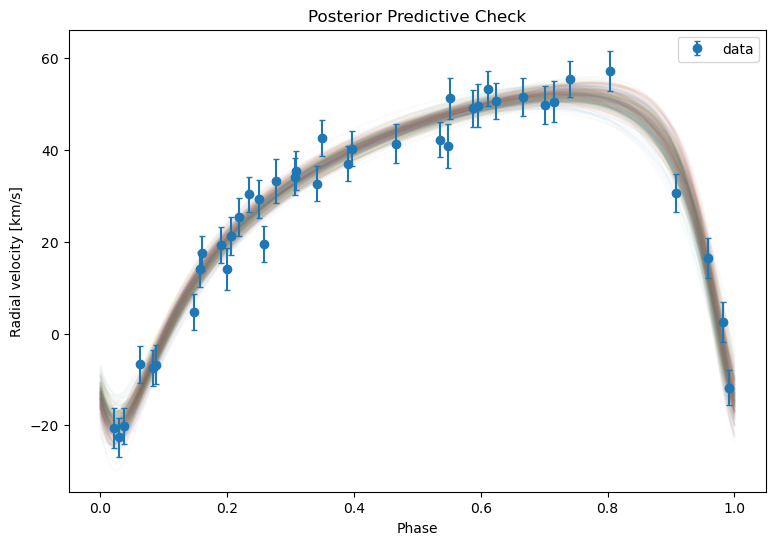

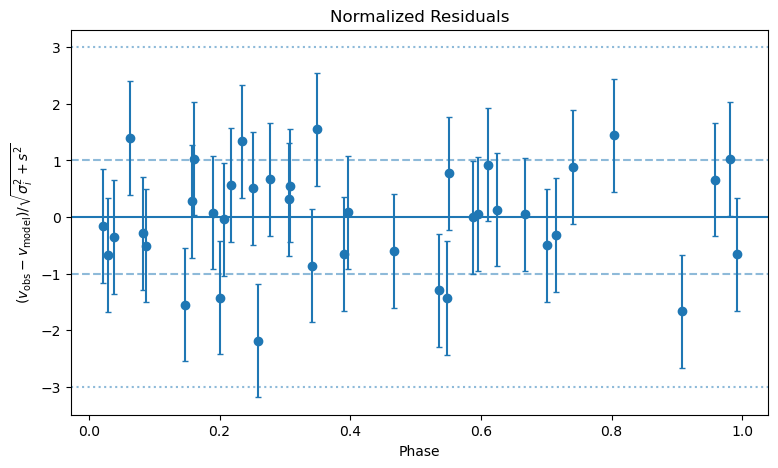

In [15]:
# ============================================================
# Part 2.6
# Posterior predictive check
# ============================================================

P_med = np.median(P_s)
Tp_med = np.median(Tp_s)
s_med = np.median(s_s)

phase_obs = ((t - Tp_med) / P_med) % 1

phase_grid = np.linspace(0, 1, 500)

t_grid = Tp_med + phase_grid * P_med

ndraw = min(300, len(flat_samples))

draw_idx = rng.choice(
    len(flat_samples),
    size=ndraw,
    replace=False
)


plt.figure(figsize=(9, 6))

for j in draw_idx:

    Pj = P_s[j]
    Kj = K_s[j]
    ej = e_s[j]
    omegaj = omega_s_raw[j]
    Tpj = Tp_s[j]
    gammaj = gamma_s[j]

    model_grid = kepler_rv(
        t_grid,
        Pj,
        Kj,
        ej,
        omegaj,
        Tpj,
        gammaj
    )

    plt.plot(
        phase_grid,
        model_grid,
        alpha=0.03
    )


# Data
plt.errorbar(
    phase_obs,
    rv,
    yerr=np.sqrt(sig**2 + s_med**2),
    fmt='o',
    capsize=2,
    label="data"
)

plt.xlabel("Phase")
plt.ylabel("Radial velocity [km/s]")
plt.title("Posterior Predictive Check")
plt.legend()
plt.show()

# Posterior median prediction at the actual observation times

prediction_draws = []

for j in draw_idx:

    prediction_draws.append(
        kepler_rv(
            t,
            P_s[j],
            K_s[j],
            e_s[j],
            omega_s_raw[j],
            Tp_s[j],
            gamma_s[j]
        )
    )

prediction_draws = np.array(prediction_draws)

model_med = np.median(
    prediction_draws,
    axis=0
)

total_error = np.sqrt(
    sig**2 + s_med**2
)

normalized_residual = (
    rv - model_med
) / total_error


plt.figure(figsize=(9, 5))

plt.errorbar(
    phase_obs,
    normalized_residual,
    yerr=np.ones_like(normalized_residual),
    fmt='o',
    capsize=2
)

plt.axhline(0)
plt.axhline(1, linestyle='--', alpha=0.5)
plt.axhline(-1, linestyle='--', alpha=0.5)
plt.axhline(3, linestyle=':', alpha=0.5)
plt.axhline(-3, linestyle=':', alpha=0.5)

plt.xlabel("Phase")
plt.ylabel(
    r"$(v_{\rm obs}-v_{\rm model})/"
    r"\sqrt{\sigma_i^2+s^2}$"
)

plt.title("Normalized Residuals")
plt.show()

**FINAL ANSWER:** $P = 265.87 \pm 1.54$ d, $K = 36.10 \pm 1.37$ km/s, $e = 0.533 \pm 0.026$, $\gamma = 31.72 \pm 0.76$ km/s, $s = 3.70 \pm 0.55$ km/s, $f(M) = 0.784 \pm 0.071\,M_\odot$

**Black-hole candidate?** No. The inferred mass function is only about
\(0.78\,M_\odot\), well below the \(\sim 3\,M_\odot\) threshold for a
black-hole candidate around a Sun-like primary.

## Part 3: The referee report (35%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident MCMC analysis of this exact
problem, produced by an AI assistant. It runs top to bottom without errors, the corner plot is handsome, and
the prose is fluent. It is also wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks and
style don't count; "it used 24 walkers and I used 32" is not a finding).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset: show, with a number or a plot, what the error
   does to the inference. For a sampler, "demonstrate" usually means running it the wrong way and the right
   way and comparing. A demonstration can come out negative: if an error turns out not to move *your*
   numbers, showing that, and saying what it would take for it to bite, is a valid finding.
3. **State** the correct treatment (you built it in Part 2).

Third time you have done this. You should be finding these in minutes now.


In [16]:
# Part 3: your work here

# ------------------------------------------------------------
# Error 1: the AI omitted the jitter term
# ------------------------------------------------------------

P_med = np.median(P_s)
K_med = np.median(K_s)
e_med = np.median(e_s)
omega_med = np.median(omega_s_raw)
Tp_med = np.median(Tp_s)
gamma_med = np.median(gamma_s)
s_med = np.median(s_s)

model_med = kepler_rv(
    t, P_med, K_med, e_med,
    omega_med, Tp_med, gamma_med
)

chi2_no_jitter = np.sum(
    ((rv - model_med) / sig)**2
) / (len(t) - 6)

chi2_with_jitter = np.sum(
    (rv - model_med)**2 /
    (sig**2 + s_med**2)
) / (len(t) - 7)

s16, s50, s84 = np.percentile(s_s, [16, 50, 84])

print("ERROR 1: OMITTING JITTER")
print(f"jitter = {s50:.3f} -{s50-s16:.3f} +{s84-s50:.3f} km/s")
print(f"reduced chi2 without jitter = {chi2_no_jitter:.3f}")
print(f"reduced chi2 with jitter    = {chi2_with_jitter:.3f}")


# ------------------------------------------------------------
# Error 2: artificially tight period prior
# ------------------------------------------------------------

P16, P50, P84 = np.percentile(P_s, [16, 50, 84])
P_width = 0.5 * (P84 - P16)

ai_prior_width = 0.5

print("\nERROR 2: PERIOD PRIOR")
print(f"Correct posterior P = {P50:.3f} +/- {P_width:.3f} d")
print(f"AI prior width       = {ai_prior_width:.3f} d")
print(f"Correct posterior is {P_width/ai_prior_width:.2f} times wider than AI prior")


# ------------------------------------------------------------
# Error 3: chain length / autocorrelation time
# ------------------------------------------------------------

tau_max = np.max(tau)

print("\nERROR 3: CONVERGENCE")
print(f"max tau from correct chain = {tau_max:.2f} steps")
print(f"AI chain length / tau      = {1500/tau_max:.2f}")
print(f"AI burn-in / tau           = {100/tau_max:.2f}")
print(f"My chain length / tau      = {10000/tau_max:.2f}")


# ------------------------------------------------------------
# Error 4: mass function propagation
# ------------------------------------------------------------

# Correct: compute f(M) for every posterior sample
f_correct = mass_function(P_s, K_s, e_s)
f16, f50, f84 = np.percentile(f_correct, [16, 50, 84])

# AI-style: compute at medians, then first-order propagation
P0 = np.median(P_s)
K0 = np.median(K_s)
e0 = np.median(e_s)

f_ai = mass_function(P0, K0, e0)

P_sd = np.std(P_s)
K_sd = np.std(K_s)
e_sd = np.std(e_s)

df_dP = f_ai / P0
df_dK = 3.0 * f_ai / K0
df_de = -3.0 * e0 * f_ai / (1.0 - e0**2)

f_ai_err = np.sqrt(
    (df_dP * P_sd)**2 +
    (df_dK * K_sd)**2 +
    (df_de * e_sd)**2
)

print("\nERROR 4: MASS FUNCTION")
print(
    f"Correct posterior: f(M) = {f50:.4f} "
    f"-{f50-f16:.4f} +{f84-f50:.4f} Msun"
)
print(
    f"AI first-order result: f(M) = "
    f"{f_ai:.4f} +/- {f_ai_err:.4f} Msun"
)

ERROR 1: OMITTING JITTER
jitter = 3.695 -0.503 +0.597 km/s
reduced chi2 without jitter = 7.610
reduced chi2 with jitter    = 1.013

ERROR 2: PERIOD PRIOR
Correct posterior P = 265.874 +/- 1.531 d
AI prior width       = 0.500 d
Correct posterior is 3.06 times wider than AI prior

ERROR 3: CONVERGENCE
max tau from correct chain = 80.86 steps
AI chain length / tau      = 18.55
AI burn-in / tau           = 1.24
My chain length / tau      = 123.67

ERROR 4: MASS FUNCTION
Correct posterior: f(M) = 0.7839 -0.0686 +0.0740 Msun
AI first-order result: f(M) = 0.7846 +/- 0.1021 Msun


**REFEREE REPORT:**

### REFEREE REPORT

The AI solution contains several substantive statistical errors.

**1. The likelihood omits the radial-velocity jitter.**  
The AI samples only the six orbital parameters and uses the quoted
measurement errors $\sigma_i$ as the full uncertainty. This is not the
likelihood specified in the problem: the variance should be
$\sigma_i^2+s^2$, where $s$ is an additional positive jitter parameter.
In my correct fit I obtain
$s = 3.70^{+0.60}_{-0.50}$ km/s, so the additional scatter is clearly
non-zero and cannot simply be ignored. Using only the quoted errors gives
a reduced $\chi^2$ of **___**, whereas including the inferred jitter gives
**___**. The correct treatment is to sample $\ln s$ and use

$$
\ln L =
-\frac{1}{2}\sum_i
\left[
\frac{(v_i-v_{\rm model,i})^2}{\sigma_i^2+s^2}
+\ln\left(2\pi(\sigma_i^2+s^2)\right)
\right].
$$

**2. The periodogram is incorrectly turned into an extremely informative
prior on the period.**  
The AI uses the same radial-velocity data to find a Lomb--Scargle peak and
then imposes a Gaussian prior of width only $0.5$ d around that peak before
using the same data again in the likelihood. This both reuses the data and
assumes that the highest sinusoidal periodogram peak uniquely identifies the
period, even though an eccentric Keplerian signal is not sinusoidal and the
seasonal gaps produce aliases. My posterior gives
$P = 265.87^{+1.57}_{-1.50}$ d, with a characteristic 68% width of about
$1.54$ d. The AI prior is therefore about 3.1 times narrower than the
period uncertainty supported by the orbital fit itself, so its claimed
sub-day precision is largely imposed by the prior. The correct treatment is
to compare maximum-likelihood Keplerian fits starting from each plausible
periodogram peak and then sample the best mode without using the periodogram
as a second, artificially tight measurement of $P$.

**3. The MCMC convergence claim is not supported by the autocorrelation
time.**  
The AI runs only 1500 steps and discards 100 steps as burn-in, then states
that the acceptance fraction and trace plots confirm convergence. In my
proper run the largest integrated autocorrelation time is about
$\tau_{\rm max}=80.9$ steps. Therefore an equivalent 1500-step chain is only
about $18.5\tau$ long, well below `emcee`'s recommended chain length of more
than $50\tau$. The proposed 100-step burn-in is also only about $1.2\tau$.
In contrast, my 10,000-step chain is about $124\tau$ long; I discarded about
$3\tau$ as burn-in and thinned by approximately $\tau/2$. Acceptance
fraction and visually smooth traces are useful diagnostics, but they do not
by themselves demonstrate convergence.

**4. The mass-function uncertainty is propagated incorrectly.**  
The AI evaluates $f(M)$ only at the median values of $P$, $K$, and $e$ and
then applies independent first-order error propagation. This is not exact:
$f(M)\propto P K^3(1-e^2)^{3/2}$ is nonlinear, and the orbital parameters
are correlated in the posterior. Applying the AI-style propagation to my
posterior gives approximately $f(M)=0.785\pm0.101\,M_\odot$, whereas
computing $f(M)$ separately for every posterior sample gives
$f(M)=0.784^{+0.074}_{-0.069}\,M_\odot$. The linear independent-error
calculation therefore overestimates the uncertainty by roughly 40% for this
dataset. The correct treatment is to transform every joint posterior sample
$(P,K,e)$ into an $f(M)$ sample and quote the 16th, 50th, and 84th
percentiles of that distribution.

## Part 4: AI-use appendix and verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did you catch it? Honesty
   is graded; "I didn't use any" is fine if true.
2. **Reflection (new from this lab on, two or three sentences)**: what did you use AI for in this lab, and
   what would have gone wrong in your answer if you had not checked its output? Name the specific thing, not
   "it could have made a mistake".
3. **Verification plan**: the checks you ran before trusting your Part 2 numbers, and what failure would have
   looked like for each. One you should seriously consider: generate a synthetic RV curve with parameters
   you choose, at *your* epochs, run your whole Part 2 pipeline on it, and see whether the 68% intervals
   contain what you put in. With seven parameters and one realisation, expect about five of seven inside
   their 68% intervals; one pull of 2.5σ is not a failure by itself. Failure looks systematic: the same
   parameter off in the same direction every time, or an interval that never contains the truth.


### AI-USE APPENDIX

I used ChatGPT throughout this lab to help interpret the instructions, draft and debug Python code for the Lomb--Scargle analysis and MCMC fit, explain the statistical reasoning, and help organize the referee report. I did not simply accept the generated output: I checked the numerical results against the plots, likelihood comparisons, autocorrelation times, posterior summaries, and the requirements stated in the lab.

One specific problem with the AI-generated code was the initial selection of candidate periods. It selected several nearby points from the same broad Lomb--Scargle peak rather than clearly independent aliases. I noticed this because all three nominal candidates converged to essentially the same Keplerian solution near $P \simeq 266$ d with the same log-likelihood. I therefore treated the periodogram as a source of starting points rather than as a precise period measurement, and checked the orbital fit and posterior directly. I also checked the AI-generated MCMC procedure using the integrated autocorrelation time instead of trusting trace plots alone.

### REFLECTION

I mainly used AI to generate and explain the MCMC implementation and to help identify statistical problems in the supplied `ai_solution.ipynb`. Without checking its output, I could have reported convergence from a visually reasonable trace plot without verifying the autocorrelation time, or accepted an artificially precise period produced by an overly restrictive period treatment. The quantitative checks showed why those conclusions needed independent verification.

### VERIFICATION PLAN

Before trusting the Part 2 parameter estimates, I would use several independent checks.

First, I would inspect the walker traces and calculate the integrated autocorrelation time $\tau$ for every parameter. My longest value was about $\tau_{\max}\approx81$ steps, while the chain contained 10,000 steps, or about $124\tau$. A failure would be a chain shorter than roughly $50\tau$, strongly drifting traces, or walkers remaining separated into different regions.

Second, I would compare maximum-likelihood Keplerian fits initialized from the plausible periodogram peaks before starting the MCMC. A failure would be another period giving a comparable or larger likelihood while the sampler explored only one mode.

Third, I would inspect the corner plot for parameter correlations and prior-boundary effects. A failure would be a posterior piled against a prior boundary or a multimodal distribution that was not explored by the walkers.

Fourth, I would perform a posterior predictive check by drawing orbital models from the posterior and comparing them with the observed radial velocities. I would examine the normalized residuals using the total uncertainty
$\sqrt{\sigma_i^2+s^2}$. A failure would be systematic residual structure with orbital phase, many large outliers, or residuals that are much broader than expected.

Finally, I would perform an injection--recovery test. I would choose known values of
$P$, $K$, $e$, $\omega$, $T_p$, $\gamma$, and $s$, generate a synthetic radial-velocity dataset at the same observing epochs with the same quoted measurement errors, and run the complete Part 2 pipeline without giving it the true values. I would then check whether the injected parameters fall within the recovered 68% credible intervals. With seven parameters and one realization I would not expect all seven to fall inside; roughly five of seven would be reasonable. A real failure would be systematic, such as repeatedly recovering the same parameter on the same side of the truth or producing intervals that consistently fail to contain the injected value.